<a href="https://colab.research.google.com/github/DTROF/intermediate-certification-1/blob/main/02_machine_failure_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Промежуточная аттестация №1

## Анализ данных промышленного оборудования и аварийных остановок

**Выполнил:** Трофимов Дмитрий

### Цель работы

Провести анализ данных о работе промышленного оборудования и показаниях датчиков, выявить закономерности, связанные с аварийными остановками оборудования, и подготовить данные для дальнейшего анализа.

### Что будет сделано

В рамках работы:
- данные подготовлены и выгружены из PostgreSQL;
- выполнен первичный анализ датасета;
- проверены пропуски, дубликаты и типы данных;
- проведена очистка и подготовка данных;
- проанализированы показатели датчиков;
- выполнено сравнение нормальной работы оборудования и аварийных остановок;
- построены графики и сформулированы основные выводы.

**Целевая переменная `is_breakdown`:**
- `0` — обычное событие оборудования;
- `1` — аварийная остановка (`BREAKDOWN`).

## 1. Загрузка и первичный анализ данных

Загружаю подготовленный в PostgreSQL датасет и проверяю его размер, структуру и первые строки.

In [1]:
# Подключаю библиотеки и загружаю датасет.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('machine_failure_dataset.csv')

print('Размер датасета:', df.shape)
df.head()

Размер датасета: (23497, 12)


,machine_event_id,machine_id,machine_code,machine_name,started_at,temperature,vibration,pressure,rpm,power,humidity,is_breakdown
0,1,1,M-001-01,Фрезерный станок с ЧПУ №1,2025-01-10 11:33:00.000 +0300,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2,1,M-001-01,Фрезерный станок с ЧПУ №1,2025-01-10 11:31:00.000 +0300,NaN,NaN,NaN,NaN,NaN,NaN,0
2,3,1,M-001-01,Фрезерный станок с ЧПУ №1,2025-01-10 12:32:00.000 +0300,70.97619,3.220704,NaN,2661.140628,1.228103,NaN,0
3,4,1,M-001-01,Фрезерный станок с ЧПУ №1,2025-01-12 09:01:00.000 +0300,70.97619,3.220704,NaN,2661.140628,1.228103,NaN,0
4,5,1,M-001-01,Фрезерный станок с ЧПУ №1,2025-01-12 08:50:00.000 +0300,70.97619,3.220704,NaN,2661.140628,1.228103,NaN,0


In [2]:
# Проверяю структуру датасета, типы данных, пропуски и дубликаты.

print('Информация о датасете:')
df.info()

print('\nКоличество пропусков:')
print(df.isnull().sum())

print('\nКоличество дубликатов:', df.duplicated().sum())

print('\nРаспределение is_breakdown:')
print(df['is_breakdown'].value_counts())

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23497 entries, 0 to 23496
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   machine_event_id  23497 non-null  int64  
 1   machine_id        23497 non-null  int64  
 2   machine_code      23497 non-null  object 
 3   machine_name      23497 non-null  object 
 4   started_at        23497 non-null  object 
 5   temperature       23303 non-null  float64
 6   vibration         14788 non-null  float64
 7   pressure          2012 non-null   float64
 8   rpm               6804 non-null   float64
 9   power             23303 non-null  float64
 10  humidity          3835 non-null   float64
 11  is_breakdown      23497 non-null  int64  
dtypes: float64(6), int64(3), object(3)
memory usage: 2.2+ MB

Количество пропусков:
machine_event_id        0
machine_id              0
machine_code            0
machine_name            0
started_at           

### Первичный вывод

Датасет содержит 23 497 наблюдений и 12 признаков. Полных дубликатов не обнаружено.

В показаниях датчиков присутствуют пропуски. Особенно много пропущенных значений в признаках `pressure`, `humidity` и `rpm`. Удаление всех строк с пропусками может привести к большой потере данных, поэтому способ обработки необходимо выбрать после доп. анализа.

Целевая переменная `is_breakdown` сильно дисбалансирована: на 23 349 обычных событий приходится только 148 аварийных остановок. Это необходимо учитывать при дальнейшей работе.

In [3]:
# Считаю количество и долю пропусков по каждому из признаков.

missing_data = pd.DataFrame({
    'Количество пропусков': df.isnull().sum(),
    'Доля пропусков, %': (df.isnull().mean() * 100).round(2)
})

missing_data

,Количество пропусков,"Доля пропусков, %"
machine_event_id,0,0.00
machine_id,0,0.00
machine_code,0,0.00
machine_name,0,0.00
started_at,0,0.00
temperature,194,0.83
vibration,8709,37.06
pressure,21485,91.44
rpm,16693,71.04
power,194,0.83


## 2. Исследование числовых признаков

Проверю основные статистические характеристики показаний датчиков. Это позволит оценить диапазоны значений и определить возможные аномалии и выбросы перед очисткой данных.

In [4]:
# Смотрю основные статистики по показаниям датчиков.

sensor_columns = [
    'temperature',
    'vibration',
    'pressure',
    'rpm',
    'power',
    'humidity'
]

df[sensor_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature,23303.0,90.253633,44.985026,48.408655,67.478802,71.928962,77.656582,217.642569
vibration,14788.0,2.597332,0.703833,0.620541,2.176719,2.528502,2.891936,6.952757
pressure,2012.0,79.962954,4.046566,66.324146,77.258740,79.865310,82.720721,92.973810
rpm,6804.0,2469.756511,201.486579,1321.907724,2373.740104,2489.120072,2596.657134,3012.532171
power,23303.0,2.649998,1.343147,0.351676,1.376369,2.718615,3.956193,5.047504
humidity,3835.0,45.019460,5.057844,28.120089,41.619750,45.134476,48.372470,61.289755


## 3. Сравнение показателей при обычной работе и авариях

Сравниваю показатели датчиков для обычных событий и аварийных. Это позволит проверить, отличаются ли параметры оборудования перед авариями от остальных событий или нет .

In [5]:
# Сравниваю медианные значения датчиков для обычных событий и аварий.

comparison = df.groupby('is_breakdown')[sensor_columns].median().T

comparison.columns = ['Обычные события', 'Аварийные остановки']

comparison

,Обычные события,Аварийные остановки
temperature,71.942211,69.609986
vibration,2.528854,2.454087
pressure,79.867820,77.586644
rpm,2488.811763,2510.240614
power,2.719321,2.545234
humidity,45.142654,43.155570


In [6]:
# Проверяю сколько показаний каждого датчика есть отдельно для обычных событий и аварий.

available_values = df.groupby('is_breakdown')[sensor_columns].count().T

available_values.columns = ['Обычные события', 'Аварийные остановки']

available_values

,Обычные события,Аварийные остановки
temperature,23155,148
vibration,14690,98
pressure,2003,9
rpm,6764,40
power,23155,148
humidity,3807,28


### Вывод по полноте показаний датчиков

Для всех 148 аварийных остановок имеются данные по температуре и мощности. Данные по вибрации доступны только для 98 аварий, поэтому этот показатель также целесоообразно использовать для дальнейшего анализа.

По RPM, влажности и особенно давлению данных меньше. Для давления имеется только 9 наблюдений при авариях, поэтому выводы по этим показателям необходимо интерпретировать с осторожно.

В дальнейшем основной анализ буду проводить по температуре, мощности и вибрации, не удаляя остальные признаки из исходного датасета.

## 4. Визуальный анализ показателей датчиков

Построим графики распределения основных показателей датчиков и сравниваем обычные события с аварийными остановками. Основное внимание уделяю температуре, мощности и вибрации, так как по этим признакам имеется достаточное количество наблюдений при авариях.

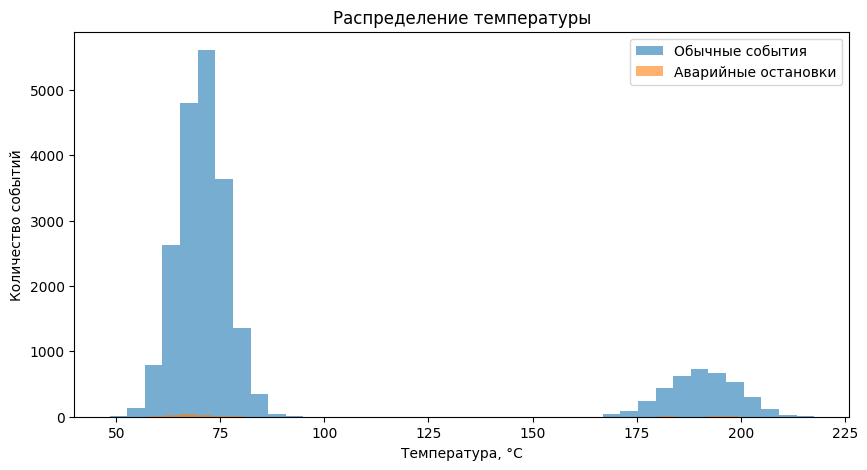

In [7]:
# Сравниваю распределение температуры при обычных событиях и авариях.

normal = df.loc[df['is_breakdown'] == 0, 'temperature'].dropna()
breakdown = df.loc[df['is_breakdown'] == 1, 'temperature'].dropna()

plt.figure(figsize=(10, 5))

plt.hist(normal, bins=40, alpha=0.6, label='Обычные события')
plt.hist(breakdown, bins=40, alpha=0.6, label='Аварийные остановки')

plt.xlabel('Температура, °C')
plt.ylabel('Количество событий')
plt.title('Распределение температуры')
plt.legend()
plt.show()

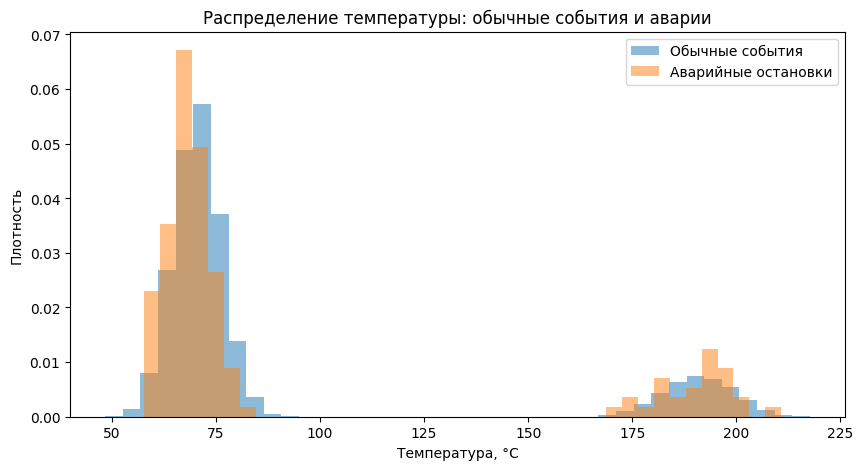

In [8]:
# Сравниваю форму распределения температуры независимо от количества событий.

plt.figure(figsize=(10, 5))

plt.hist(
    normal,
    bins=40,
    density=True,
    alpha=0.5,
    label='Обычные события'
)

plt.hist(
    breakdown,
    bins=40,
    density=True,
    alpha=0.5,
    label='Аварийные остановки'
)

plt.xlabel('Температура, °C')
plt.ylabel('Плотность')
plt.title('Распределение температуры: обычные события и аварии')
plt.legend()
plt.show()

### Вывод по температуре

Распределение температуры имеет 2 выраженных диапазона: примерно 60–85 °C и 170–210 °C. Второй диапазон встречается как при обычных событиях, так и при аварийных остановках, поэтому считать эти значения ошибочными выбросами без дополнительного анализа нельзя.

Форма распределения температуры для обычных событий и аварий в целом похожа. На данном этапе температура сама по себе не показывает явного разделения между обычной работой оборудования и аварийными остановками.

In [9]:
# Проверяю на каком оборудовании встречаются высокие температуры.

high_temperature = (
    df[df['temperature'] > 150]
    .groupby(['machine_code', 'machine_name'])
    .size()
    .sort_values(ascending=False)
)

high_temperature.head(15)

,,0
machine_code,machine_name,
M-019-01,Промышленная термическая печь №1,314
M-018-01,Промышленная термическая печь №1,284
M-022-02,Промышленная термическая печь №2,279
M-007-03,Промышленная термическая печь №3,275
M-007-04,Промышленная термическая печь №4,271
M-014-02,Промышленная термическая печь №2,269
M-002-02,Промышленная термическая печь №2,269
M-002-01,Промышленная термическая печь №1,258
M-007-02,Промышленная термическая печь №2,249


### Анализ высоких значений температуры

Проверка показала, что температуры выше 150 °C относятся к промышленным термическим печам. Следовательно, второй диапазон температур на графике связан с особенностями конкретного оборудования, а не с ошибками или случайными выбросами.

Поэтому высокие значения температуры не удаляю из датасета. При дальнейшем анализе необходимо учитывать, что нормальный диапазон показаний датчиков может зависеть от типа оборудования.

In [10]:
# Смотрю на каком оборудовании происходили аварийные остановки.

breakdowns_by_machine = (
    df[df['is_breakdown'] == 1]
    .groupby(['machine_code', 'machine_name'])
    .size()
    .sort_values(ascending=False)
)

breakdowns_by_machine.head(15)

,,0
machine_code,machine_name,
M-020-02,Промышленный робот №2,6
M-002-01,Промышленная термическая печь №1,5
M-010-01,Сварочный робот №1,4
M-014-03,Токарный станок с ЧПУ №3,4
M-020-01,Промышленный робот №1,4
M-017-01,Промышленный робот №1,4
M-007-03,Промышленная термическая печь №3,4
M-014-01,Фрезерный станок с ЧПУ №1,4
M-001-03,Промышленная термическая печь №3,3


### Вывод по распределению аварий

Аварийные остановки распределены между разными машинами и типами оборудования. В выборке присутствуют промышленные роботы, термические печи, станки с ЧПУ, сварочные роботы и другое оборудование.

Явной концентрации аварий на одной конкретной машине не наблюдается. Поэтому дальнейший анализ показаний датчиков имеет смысл проводить по всей выборке, учитывая различия между типами оборудования.

## 5. Очистка и подготовка данных

Перед дальнейшим анализом подготавливаю данные. Полные дубликаты в датасете отсутствуют.

Высокие значения температуры не удаляю, поскольку анализ показал, что они относятся к промышленным термическим печам и являются нормальными для данного типа оборудования.

Признаки с большим количеством пропусков не заполняю искусственными значениями, поскольку это может существенно исказить реальные показания датчиков. Для каждого анализа использую только фактически имеющиеся значения соответствующего признака.

Столбец `started_at` преобразую в формат даты и времени.

### Что в итоге сделал с данными

Перед дальнейшим анализом отдельно проверил пропуски, дубликаты и возможные выбросы.

Полных дубликатов в датасете нет, поэтому удалять их не потребовалось.

По пропускам ситуация разная. В `temperature` и `power` пропусков совсем немного — около 1%. В `vibration` их уже заметно больше, а в `pressure`, `rpm` и `humidity` отсутствует большая часть значений. Заполнять такие пропуски средним или медианой не стал, потому что можно получить искусственные значения, которых датчики на самом деле не передавали. Поэтому в анализе каждого показателя использую только строки, где этот показатель реально есть.

Высокие значения температуры тоже не удалял. Дополнительная проверка показала, что они относятся к промышленным термическим печам, то есть это нормальные значения для данного типа оборудования, а не ошибка данных.

Поле `started_at` преобразовал в формат даты и времени. Некорректных дат после преобразования не обнаружено.

Таким образом, исходные значения датчиков сохраняю без искусственного заполнения и удаления. При анализе конкретного показателя пропуски исключаю только для этого показателя через `dropna()`.

In [17]:
# Преобразую время события в формат datetime.

df['started_at'] = pd.to_datetime(df['started_at'], errors='coerce', utc=True)

print('Тип started_at:', df['started_at'].dtype)
print('Некорректных дат:', df['started_at'].isna().sum())

Тип started_at: datetime64[ns, UTC]
Некорректных дат: 0


## 6. Анализ мощности и вибрации

Температура не показала явного разделения обычных и аварийных событий. Дополнительно анализирую мощность и вибрацию оборудования — признаки, для которых имеется достаточное количество фактических наблюдений.

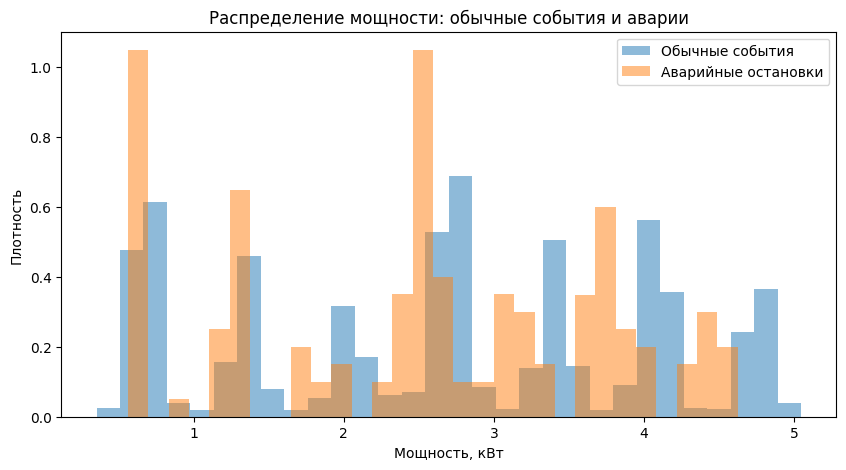

In [12]:
# Сравниваю распределение мощности при обычных событиях и авариях.

normal_power = df.loc[df['is_breakdown'] == 0, 'power'].dropna()
breakdown_power = df.loc[df['is_breakdown'] == 1, 'power'].dropna()

plt.figure(figsize=(10, 5))

plt.hist(normal_power, bins=30, density=True, alpha=0.5,
         label='Обычные события')
plt.hist(breakdown_power, bins=30, density=True, alpha=0.5,
         label='Аварийные остановки')

plt.xlabel('Мощность, кВт')
plt.ylabel('Плотность')
plt.title('Распределение мощности: обычные события и аварии')
plt.legend()
plt.show()

### Вывод по мощности

Распределения мощности для обычных событий и аварийных частично различаются, но значительно пересекаются. Явного значения мощности, которое однозначно отделяло бы аварийные события от обычных, не наблюдается.

Следовательно, мощность может быть полезна в сочетании с другими показателями, но сама по себе не является достаточным признаком аварийной остановки.

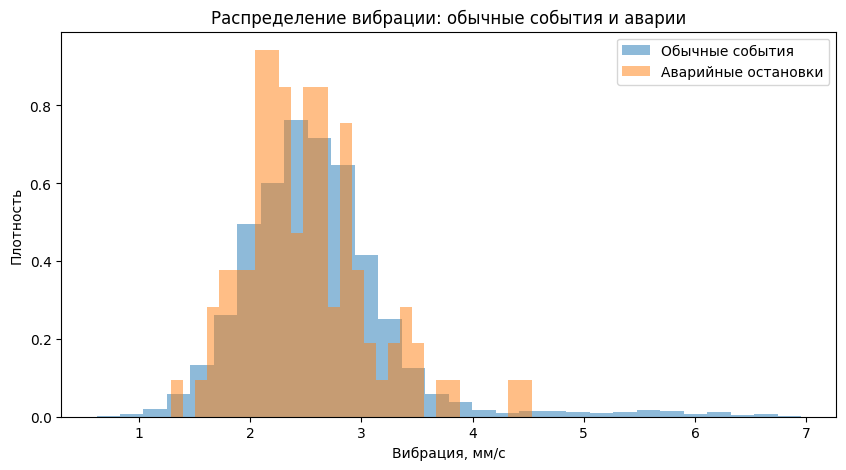

In [13]:
# Сравниваю распределение вибрации при обычных событиях и авариях.

normal_vibration = df.loc[df['is_breakdown'] == 0, 'vibration'].dropna()
breakdown_vibration = df.loc[df['is_breakdown'] == 1, 'vibration'].dropna()

plt.figure(figsize=(10, 5))

plt.hist(normal_vibration, bins=30, density=True, alpha=0.5,
         label='Обычные события')
plt.hist(breakdown_vibration, bins=30, density=True, alpha=0.5,
         label='Аварийные остановки')

plt.xlabel('Вибрация, мм/с')
plt.ylabel('Плотность')
plt.title('Распределение вибрации: обычные события и аварии')
plt.legend()
plt.show()

### Вывод по вибрации

Распределения вибрации при обычных событиях и аварийных  значительно пересекаются. Основная часть наблюдений в обоих случаях находится примерно в диапазоне 2–3 мм/с.

Высокие значения вибрации встречаются и при обычной работе оборудования. Поэтому по одному показателю вибрации однозначно определить аварийную остановку нельзя.

## 7. Корреляционный анализ

Проверяю взаимосвязь между числовыми показателями датчиков и целевой переменной `is_breakdown`. Это позволит оценить, есть ли признаки с выраженной линейной связью с аварийными остановками.

In [14]:
# Рассчитываю корреляции между показателями датчиков и аварийными остановками.

correlation_columns = sensor_columns + ['is_breakdown']

correlation_matrix = df[correlation_columns].corr()

correlation_matrix.round(3)

,temperature,vibration,pressure,rpm,power,humidity,is_breakdown
temperature,1.000,0.000,-0.003,0.135,0.455,-0.036,0.002
vibration,0.000,1.000,NaN,0.009,0.007,NaN,-0.010
pressure,-0.003,NaN,1.000,NaN,0.031,NaN,-0.011
rpm,0.135,0.009,NaN,1.000,0.062,NaN,0.024
power,0.455,0.007,0.031,0.062,1.000,0.000,-0.007
humidity,-0.036,NaN,NaN,NaN,0.000,1.000,-0.005
is_breakdown,0.002,-0.010,-0.011,0.024,-0.007,-0.005,1.000


### Вывод по корреляционному анализу

Корреляционный анализ не выявил сильной связи между отдельными показателями датчиков и аварийными остановками.

Все коэффициенты корреляции с `is_breakdown` близки к нулю. Наибольшее значение получено для RPM — около 0,024, что также соответствует очень слабой связи.

При этом между некоторыми показателями самих датчиков наблюдается связь. Например, коэффициент корреляции температуры и мощности составляет около 0,455.

Полученные результаты подтверждают, что определять аварийную остановку только по одному показателю датчика некорректно. Для дальнейшего прогнозирования необходимо рассматривать сочетание нескольких признаков и учитывать тип оборудования.

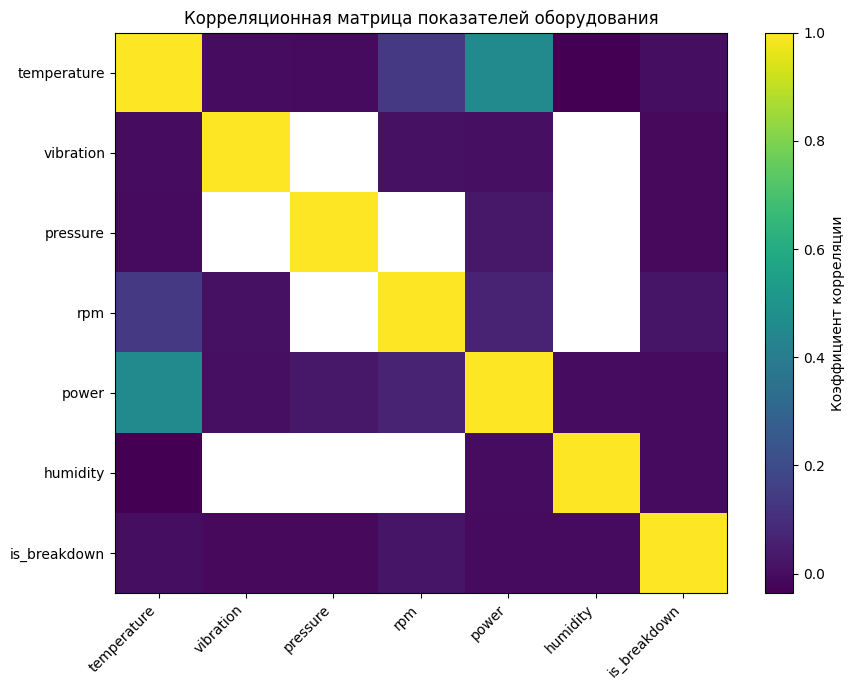

In [15]:
# Визуализирую корреляционную матрицу.

plt.figure(figsize=(9, 7))

plt.imshow(correlation_matrix, aspect='auto')
plt.colorbar(label='Коэффициент корреляции')

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title('Корреляционная матрица показателей оборудования')
plt.tight_layout()
plt.show()

### Вывод по корреляционной матрице

Визуализация подтверждает отсутствие выраженной линейной связи между отдельными показателями датчиков и аварийными остановками.

Наиболее заметная связь среди показателей оборудования наблюдается между температурой и мощностью. При этом значения корреляции признаков с `is_breakdown` близки к нулю.

Следовательно, для анализа аварий недостаточно использовать один показатель датчика. Необходимо учитывать совокупность признаков, тип оборудования и особенности его режима работы.

## 8. Что получилось по результатам анализа

В датасете 23 497 событий оборудования, из них 148 аварийных остановок. Аварий значительно меньше обычных событий, поэтому выборка сильно несбалансирована.

По отдельным показателям датчиков явного признака аварии я не нашел. Температура, мощность и вибрация при обычной работе и авариях сильно пересекаются.

Высокая температура сначала выглядела как возможный выброс, но проверка показала, что такие значения относятся к промышленным термическим печам. Поэтому удалять их из данных было бы неправильно.

По части датчиков много пропусков. Особенно это касается давления, влажности и RPM. Заполнять большую часть таких данных средними или медианными значениями я не стал, чтобы не создавать искусственные показания.

Корреляция отдельных показателей с авариями также оказалась очень слабой. Значит, определить аварийную остановку только по температуре, мощности или вибрации не получится.

Для более точного определения аварий дальше нужно учитывать несколько показателей одновременно, а также тип оборудования и режим его работы.

## 9. Проверка гипотез

После первичного анализа данных хочу проверить несколько гипотез, которые могут быть связаны с аварийными остановками оборудования.

**Гипотеза 1. Температура оборудования перед авариями отличается от температуры при обычной работе.**

Если температура действительно связана с авариями, распределение и типичные значения температуры для аварийных событий должны отличаться от обычных.
**Практический смысл:** если перед авариями температура действительно меняется, этот показатель можно использовать для раннего обнаружения перегрева или ненормального режима работы оборудования.

**Гипотеза 2. Вибрация оборудования перед авариями отличается от обычного режима работы.**

Повышенная или изменившаяся вибрация может быть признаком проблем с оборудованием, поэтому сравню значения вибрации для двух групп событий.

**Практический смысл: ** если перед авариями вибрация отличается от обычного режима, ее можно использовать как один из признаков износа или появления механической неисправности.

**Гипотеза 3. Мощность оборудования перед авариями отличается от мощности при обычной работе.**

Изменение потребляемой мощности может быть связано с изменением режима работы оборудования или возникновением неисправности.

**Практический смысл:** если перед авариями меняется потребляемая мощность, это может помочь заметить изменение нагрузки или ненормальный режим работы оборудования до остановки.
Проверю эти гипотезы на имеющихся данных и посмотрю, насколько заметны различия между обычными событиями и аварийными остановками.

In [16]:
# Сравниваю основные показатели при обычной работе и авариях.

hypothesis_result = df.groupby('is_breakdown')[
    ['temperature', 'vibration', 'power']
].agg(['count', 'mean', 'median'])

hypothesis_result

temperature                       vibration                      \
                   count       mean     median     count      mean    median   
is_breakdown                                                                   
0                  23155  90.246694  71.942211     14690  2.597925  2.528854   
1                    148  91.339173  69.609986        98  2.508579  2.454087   

              power                      
              count      mean    median  
is_breakdown                             
0             23155  2.650775  2.719321  
1               148  2.528382  2.545234

### Вывод по гипотезам

По температуре заметного различия между обычными событиями и авариями не получилось. Средние значения практически одинаковые, а медиана при авариях даже немного ниже. Поэтому первая гипотеза по нашим данным не подтверждается.

По вибрации картина примерно такая же. При авариях среднее и медиана немного ниже, но разница небольшая. Явной связи вибрации с аварийными остановками здесь не видно.

По мощности тоже нет сильного различия. При авариях среднее значение мощности немного ниже обычного режима, но распределения, как было видно на графике, сильно пересекаются.

В итоге ни один из трех показателей сам по себе не дает хорошего разделения обычной работы и аварий. Скорее всего, для поиска аварий нужно смотреть не один датчик, а сочетание нескольких параметров и учитывать тип конкретного оборудования.

## 10. Итоговые выводы

В этой работе я использовал производственную базу данных `manufacturing` и выбрал задачу анализа аварийных остановок оборудования.

В PostgreSQL подготовил представление `vw_machine_failure_dataset`, в котором собрал события оборудования и последние доступные показания датчиков перед событием. В качестве целевой переменной использовал `is_breakdown`: 1 — аварийная остановка, 0 — остальные события.

В итоговый датасет вошло 23 497 событий, из них 148 аварийных. Поэтому сразу видно, что аварии встречаются редко и выборка сильно несбалансирована.

При анализе обнаружилось много пропусков по отдельным датчикам. Особенно это касается давления, влажности и RPM. Я не стал заполнять большую часть отсутствующих показаний средними значениями, потому что это создало бы искусственные данные.

Отдельно проверил высокие значения температуры. Сначала они выглядели как возможные выбросы, но оказалось, что такие температуры относятся к промышленным термическим печам. Поэтому удалять их было бы неправильно.

Дальше сравнил температуру, вибрацию и мощность при обычных событиях и аварийных остановках. Сильных различий по отдельным показателям не получилось. Корреляция этих признаков с `is_breakdown` тоже оказалась очень слабой.

Проверенные гипотезы о связи температуры, вибрации и мощности с авариями однозначно не подтвердились. Это не значит, что показания датчиков бесполезны. Скорее, по одному параметру определить приближение аварии недостаточно.

### Практический результат

Для дальнейшего решения задачи я бы использовал сразу несколько показателей датчиков и обязательно учитывал тип оборудования. Например, одинаковая температура может быть нормальной для промышленной печи и ненормальной для другого оборудования.

Следующим этапом можно построить модель классификации, которая будет оценивать вероятность аварии по совокупности признаков. При этом отдельно нужно учитывать сильный дисбаланс классов и разную полноту данных по датчикам.

С практической точки зрения такое решение в дальнейшем можно использовать для раннего предупреждения о возможных неисправностях и планирования обслуживания оборудования до аварийной остановки.
